In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# ── DATA CLEANING ──

# 1. Fix date columns (convert from string to datetime)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 2. Extract useful time columns
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')

# 3. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# 4. Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# 5. Basic stats on key columns
print("\nKey column stats:")
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(2))

Missing values per column:
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Order Year          0
Order Month         0
Order Month Name    0
dtype: int64

Duplicate rows: 0

Key column stats:
          Sales   Profit  Discount  Quantity
count   9994.00  9994.00   9994.00   9994.00
mean     229.86    28.66      0.16      3.79
std      623.25   234.26      0.21      2.23
min        0.44 -6599.98      0.00      1.00
25%       17.28     1.73      0.00      2.00
50%       54.49     8.67      0.20      3.00
75%      209.94    29.36      0.20      5.00
max    22638.48  8399.98      0.80

In [3]:
# ── SQL ANALYSIS ──

# Load dataframe into a SQLite database (no installation needed)
conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, index=False, if_exists='replace')

# ── Query 1: Total Sales & Profit by Region ──
q1 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND(AVG(Discount) * 100, 1) AS Avg_Discount_Pct
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)
print("── Sales & Profit by Region ──")
print(q1)

# ── Query 2: Monthly Revenue Trend ──
q2 = pd.read_sql_query("""
    SELECT "Order Year" AS Year,
           "Order Month" AS Month,
           "Order Month Name" AS Month_Name,
           ROUND(SUM(Sales), 2) AS Monthly_Sales
    FROM superstore
    GROUP BY Year, Month
    ORDER BY Year, Month
""", conn)
print("\n── Monthly Sales Trend (last 6 rows) ──")
print(q2.tail(6))

# ── Query 3: Most Profitable & Loss-Making Sub-Categories ──
q3 = pd.read_sql_query("""
    SELECT "Sub-Category",
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY "Sub-Category"
    ORDER BY Total_Profit DESC
""", conn)
print("\n── Profit by Sub-Category (Top 5 & Bottom 3) ──")
print(pd.concat([q3.head(5), q3.tail(3)]))

── Sales & Profit by Region ──
    Region  Total_Sales  Total_Profit  Avg_Discount_Pct
0     West    725457.82     108418.45              10.9
1     East    678781.24      91522.78              14.5
2  Central    501239.89      39706.36              24.0
3    South    391721.91      46749.43              14.7

── Monthly Sales Trend (last 6 rows) ──
    Year  Month Month_Name  Monthly_Sales
42  2017      7        Jul       45264.42
43  2017      8        Aug       63120.89
44  2017      9        Sep       87866.65
45  2017     10        Oct       77776.92
46  2017     11        Nov      118447.82
47  2017     12        Dec       83829.32

── Profit by Sub-Category (Top 5 & Bottom 3) ──
   Sub-Category  Total_Profit  Total_Sales
0       Copiers      55617.82    149528.03
1        Phones      44515.73    330007.05
2   Accessories      41936.64    167380.32
3         Paper      34053.57     78479.21
4       Binders      30221.76    203412.73
14     Supplies      -1189.10     46673.54
15  

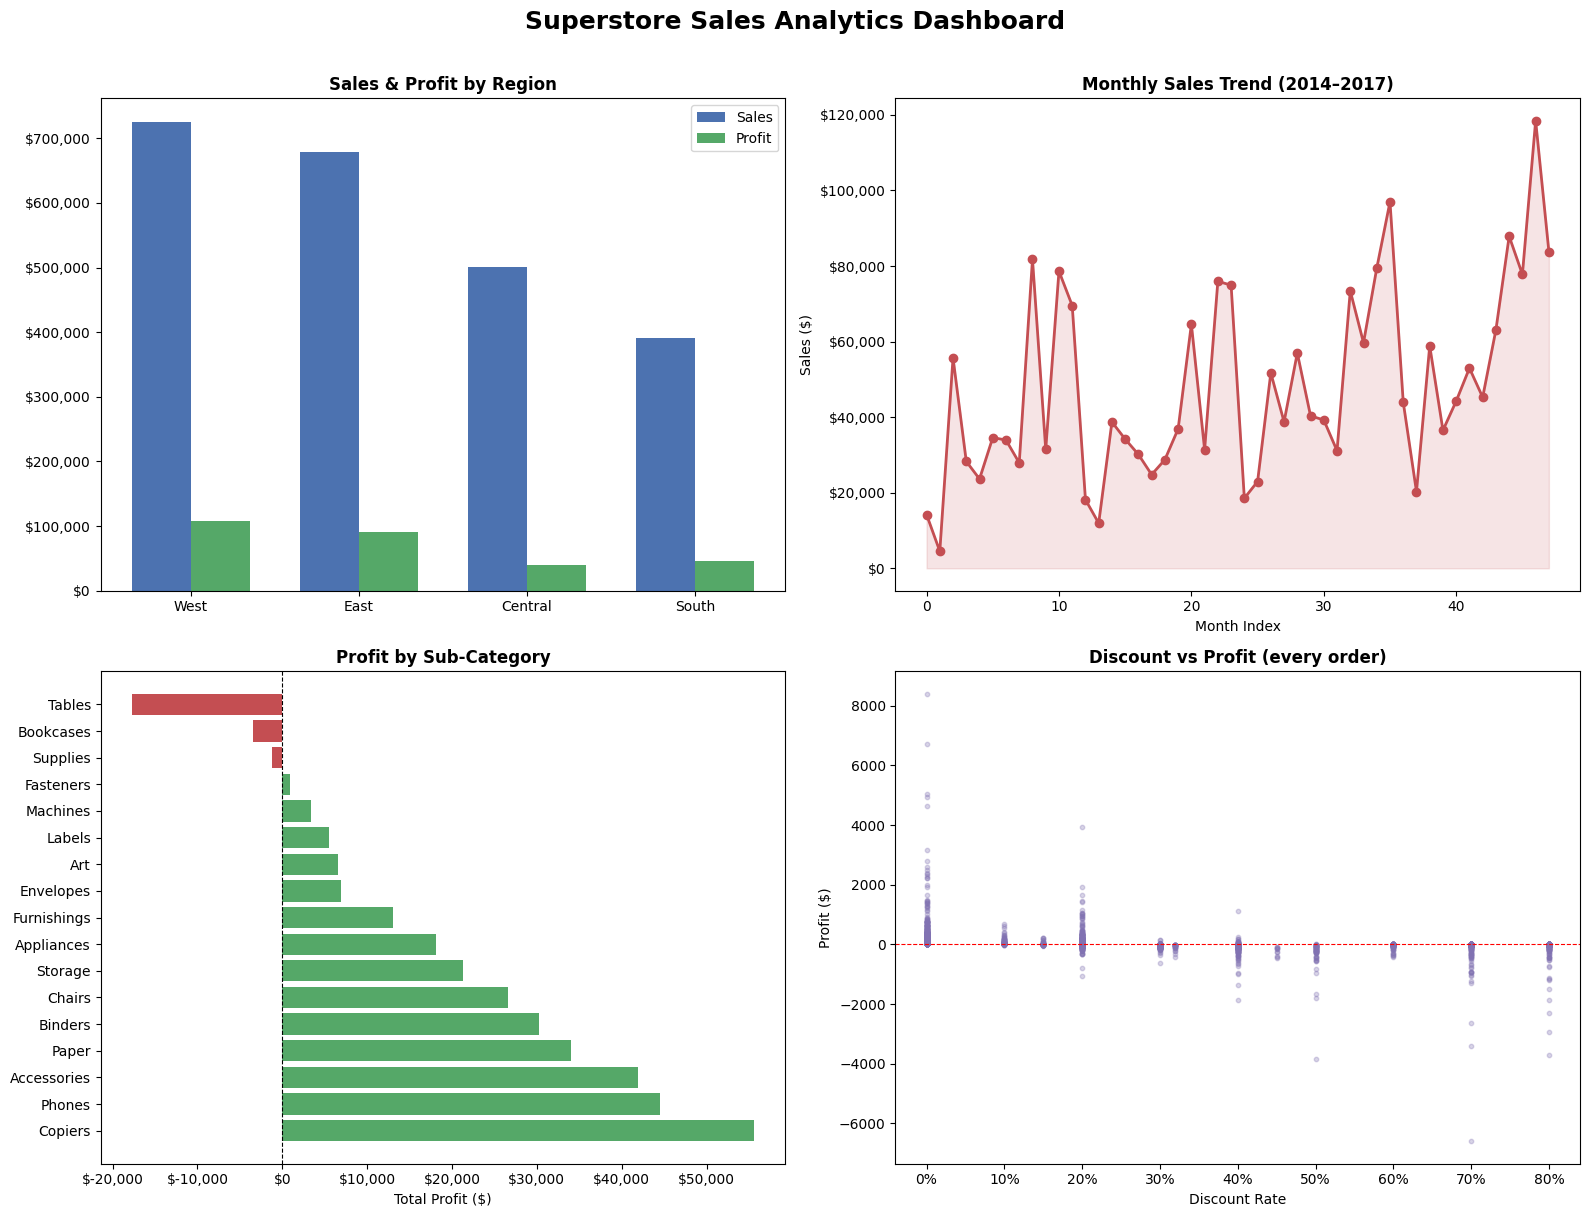

✅ Dashboard saved as dashboard.png


In [4]:
# ── VISUALIZATIONS ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Superstore Sales Analytics Dashboard', fontsize=18, fontweight='bold', y=1.01)

# ── Chart 1: Sales & Profit by Region ──
x = range(len(q1['Region']))
width = 0.35
axes[0,0].bar([i - width/2 for i in x], q1['Total_Sales'], width, label='Sales', color='#4C72B0')
axes[0,0].bar([i + width/2 for i in x], q1['Total_Profit'], width, label='Profit', color='#55A868')
axes[0,0].set_xticks(list(x))
axes[0,0].set_xticklabels(q1['Region'])
axes[0,0].set_title('Sales & Profit by Region', fontweight='bold')
axes[0,0].legend()
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:,.0f}'))

# ── Chart 2: Monthly Sales Trend ──
axes[0,1].plot(range(len(q2)), q2['Monthly_Sales'], marker='o', color='#C44E52', linewidth=2)
axes[0,1].set_title('Monthly Sales Trend (2014–2017)', fontweight='bold')
axes[0,1].set_xlabel('Month Index')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:,.0f}'))
axes[0,1].fill_between(range(len(q2)), q2['Monthly_Sales'], alpha=0.15, color='#C44E52')

# ── Chart 3: Top & Bottom Sub-Categories by Profit ──
colors = ['#55A868' if p > 0 else '#C44E52' for p in q3['Total_Profit']]
axes[1,0].barh(q3['Sub-Category'], q3['Total_Profit'], color=colors)
axes[1,0].set_title('Profit by Sub-Category', fontweight='bold')
axes[1,0].set_xlabel('Total Profit ($)')
axes[1,0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:,.0f}'))

# ── Chart 4: Discount vs Profit (scatter) ──
axes[1,1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#8172B2', s=10)
axes[1,1].set_title('Discount vs Profit (every order)', fontweight='bold')
axes[1,1].set_xlabel('Discount Rate')
axes[1,1].set_ylabel('Profit ($)')
axes[1,1].axhline(y=0, color='red', linewidth=0.8, linestyle='--')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.0%}'))

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as dashboard.png")

In [5]:
# ── EXPORT FOR TABLEAU ──

# Summary tables for Tableau
regional_summary = pd.read_sql_query("""
    SELECT Region, Category,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND(AVG(Discount)*100, 1) AS Avg_Discount_Pct,
           COUNT(DISTINCT "Order ID") AS Total_Orders
    FROM superstore
    GROUP BY Region, Category
    ORDER BY Region, Total_Sales DESC
""", conn)

monthly_trend = pd.read_sql_query("""
    SELECT "Order Year" AS Year,
           "Order Month" AS Month,
           "Order Month Name" AS Month_Name,
           Category,
           ROUND(SUM(Sales), 2) AS Monthly_Sales,
           ROUND(SUM(Profit), 2) AS Monthly_Profit
    FROM superstore
    GROUP BY Year, Month, Category
    ORDER BY Year, Month
""", conn)

# Save exports
df.to_csv('superstore_clean.csv', index=False)
regional_summary.to_csv('regional_summary.csv', index=False)
monthly_trend.to_csv('monthly_trend.csv', index=False)

print("✅ Files saved:")
print("   - superstore_clean.csv  (full clean dataset)")
print("   - regional_summary.csv  (for Tableau regional view)")
print("   - monthly_trend.csv     (for Tableau trend view)")
print(f"\nTotal records exported: {len(df)}")

✅ Files saved:
   - superstore_clean.csv  (full clean dataset)
   - regional_summary.csv  (for Tableau regional view)
   - monthly_trend.csv     (for Tableau trend view)

Total records exported: 9994


In [6]:
# ── EXPORT FOR POWER BI ──
import openpyxl

# Save all sheets into one Excel file for Power BI
with pd.ExcelWriter('superstore_powerbi.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Full Data', index=False)
    regional_summary.to_excel(writer, sheet_name='Regional Summary', index=False)
    monthly_trend.to_excel(writer, sheet_name='Monthly Trend', index=False)
    q3.to_excel(writer, sheet_name='SubCategory Profit', index=False)

print("✅ superstore_powerbi.xlsx saved!")
print("   Sheets: Full Data, Regional Summary, Monthly Trend, SubCategory Profit")

ModuleNotFoundError: No module named 'openpyxl'

In [7]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\vansh\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [8]:
import os
files = os.listdir('.')
print("Files in your project folder:")
for f in files:
    print(f)

Files in your project folder:
.ipynb_checkpoints
dashboard.png
monthly_trend.csv
regional_summary.csv
sales_analysis.ipynb
Sample - Superstore.csv
superstore_clean.csv


In [9]:
import subprocess
subprocess.run(['pip', 'install', 'openpyxl'], capture_output=True)

# Now retry the export
import importlib
import openpyxl

with pd.ExcelWriter('superstore_powerbi.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Full Data', index=False)
    regional_summary.to_excel(writer, sheet_name='Regional Summary', index=False)
    monthly_trend.to_excel(writer, sheet_name='Monthly Trend', index=False)
    q3.to_excel(writer, sheet_name='SubCategory Profit', index=False)

print("✅ superstore_powerbi.xlsx saved!")

✅ superstore_powerbi.xlsx saved!


In [10]:
import os
files = os.listdir('.')
print("Files in your project folder:")
for f in files:
    print(f)

Files in your project folder:
.ipynb_checkpoints
dashboard.png
monthly_trend.csv
regional_summary.csv
sales_analysis.ipynb
Sample - Superstore.csv
superstore_clean.csv
superstore_powerbi.xlsx
